# 14. Online elimination-based co-design

When a co-design problem has many discrete candidates (catalog entries, robot types, component families) and each candidate's inner solve is non-trivial, evaluating every one is wasteful. The `codesign.online` module implements the elimination-based solver from Alharbi, Dahleh & Zardini (2026): maintain *optimistic bounds* on each candidate's inner-solve output, evaluate the most promising one, then prune any candidate whose lower bound is already dominated by what we know.

This notebook reproduces the spirit of the multi-robot fleet case study. A logistics service must hit a target throughput over a target range, and can buy robots from a catalog of N=200 candidate types. We solve it three ways:

- **Lipschitz**: the most general assumption (bounded variation), the most reliable, modest pruning.
- **Monotonicity**: cheapest when applicable; needs a feature under which the output is genuinely monotone.
- **LinearParametric**: now the *certified* confidence-polytope bound of the paper (Sec. V-C3). It is guaranteed never to prune a Pareto-optimal candidate; it is exact and aggressive only when the resource map is genuinely affine in the features.


## The problem

In [1]:
import math, random
from codesign import (
    AlgebraicDP, Reals, Ports, solve,
    solve_online, LipschitzEvaluator,
    MonotonicityEvaluator, LinearParametricEvaluator,
)

# Mission spec: deliver `target_throughput` packages per hour over
# `target_range` km of daily travel.
F = Ports({"target_throughput": Reals(unit="pkg/h"),
                  "target_range":      Reals(unit="km")})
# What the fleet costs: dollars to acquire + kWh to operate.
R = Ports({"total_cost":   Reals(unit="USD"),
                  "total_energy": Reals(unit="kWh/day")})

def make_dp(robot):
    # Closed-form inner solve per robot type. capacity = speed * payload
    # is packages/hour per single robot; total_cost is the fleet size
    # times unit_cost; total_energy is range times per-km energy times
    # 24 hours of duty cycle.
    s = robot["speed"]; p = robot["payload"]
    c = robot["unit_cost"]; e = robot["energy_per_km"]
    capacity = s * p  # pkg/h per robot
    # Default-argument trick captures the loop-variable values at lambda
    # creation time, so each AlgebraicDP closes over its own robot's specs.
    return AlgebraicDP(F, R, {
        "total_cost":   lambda f, cap=capacity, uc=c: (f["target_throughput"]/cap) * uc,
        "total_energy": lambda f, ek=e: f["target_range"] * ek * 24.0,
    })

## The catalog (200 robot types)

In [2]:
def make_catalog(n=200, seed=42):
    # Random robot specs in physically plausible ranges. Seeded for
    # reproducibility across notebook runs.
    rng = random.Random(seed)
    out = []
    for i in range(n):
        s = rng.uniform(5, 30); p = rng.uniform(1, 20)
        c = rng.uniform(500, 5000); e = rng.uniform(0.05, 0.5)
        out.append({"name": f"r{i:03d}",
                    "speed": s, "payload": p,
                    "unit_cost": c, "energy_per_km": e,
                    # Derived feature: total_cost is exactly proportional
                    # to this scalar (T * cost_per_capacity), so it's a
                    # genuinely monotone feature the MonotonicityEvaluator
                    # can exploit aggressively.
                    "cost_per_capacity": c / (s * p)})
    return out

candidates = make_catalog()
mission = {"target_throughput": 100.0, "target_range": 50.0}
print(f"{len(candidates)} candidate robot types")

200 candidate robot types


## Exhaustive baseline

Every catalog entry gets solved; we record the true Pareto front for reference.


In [3]:
# Run solve() on every candidate. With 200 entries this is the cost
# we want the online learner to reduce.
points = []
for c in candidates:
    a = solve(make_dp(c), mission).antichain
    pt = dict(list(a.points)[0]); pt["name"] = c["name"]
    points.append(pt)

# Compute the true Pareto front by brute force: a point is Pareto-optimal
# if no other point dominates it (i.e., is <= in every R component and
# strictly < in at least one).
pareto = []
for p in points:
    dominated = any(
        q["total_cost"] <= p["total_cost"] and q["total_energy"] <= p["total_energy"]
        and (q["total_cost"] < p["total_cost"] or q["total_energy"] < p["total_energy"])
        for q in points
    )
    if not dominated:
        pareto.append(p)
pareto.sort(key=lambda x: x["total_cost"])
print(f"True Pareto front: {len(pareto)} non-dominated robot types")
for p in pareto:
    print(f"  {p['name']}: cost={p['total_cost']:7.2f}, energy={p['total_energy']:6.2f}")

True Pareto front: 5 non-dominated robot types
  r033: cost= 172.99, energy=322.43
  r135: cost= 200.27, energy= 73.87
  r103: cost=1214.50, energy= 73.19
  r004: cost=3231.41, energy= 63.51
  r106: cost=3528.74, energy= 62.99


## Online with three evaluators

Each evaluator encodes a different prior belief about how candidate features relate to the inner-solve output.


In [4]:
# Three evaluators with different structural assumptions.
evs = [
    # Lipschitz: bounded variation. Safest default; L tunes the trade-off
    # between pruning aggressiveness and risk of missing a Pareto point.
    ("Lipschitz", LipschitzEvaluator(
        features=["speed", "payload", "unit_cost", "energy_per_km"],
        r_components=["total_cost", "total_energy"],
        L={"total_cost": 300.0, "total_energy": 30.0},
    )),
    # Monotonicity on the derived feature: total_cost is exactly
    # proportional to cost_per_capacity, so one observation prunes
    # everything strictly worse in features.
    ("Monotonicity", MonotonicityEvaluator(
        features=["cost_per_capacity", "energy_per_km"],
        r_components=["total_cost", "total_energy"],
    )),
    # LinearParametric: the certified confidence-polytope bound of the
    # paper (Sec. V-C3). It maintains the polytope of linear parameter
    # vectors consistent with every observation and lower-bounds each
    # query by one LP over that polytope, so the bound is guaranteed and
    # it never wrongly eliminates a Pareto point. min_obs=5 means it only
    # starts bounding after five evaluations.
    ("LinearParametric (certified)", LinearParametricEvaluator(
        features=["speed", "payload", "unit_cost", "energy_per_km"],
        r_components=["total_cost", "total_energy"],
        min_obs=5,
    )),
]
results = []
for name, ev in evs:
    # solve_online prunes candidates by bound, then evaluates the most
    # promising survivor via the standard solver. Loop until exhausted
    # or budget hit (unset here, so unbounded).
    res = solve_online(make_dp, mission, candidates=candidates, evaluator=ev)
    results.append((name, res))
    print(f"{name:<18}: {res.n_evaluated:>3} evals, {res.n_eliminated:>3} eliminated, "
          f"antichain size {len(res.antichain)}")

Lipschitz         : 192 evals,   8 eliminated, antichain size 5
Monotonicity      :  13 evals, 187 eliminated, antichain size 5


LinearParametric (certified): 122 evals,  78 eliminated, antichain size 5


## Visualising the elimination cascade

Plotting the catalog in feature space, coloured by status. Stars mark the true Pareto front.


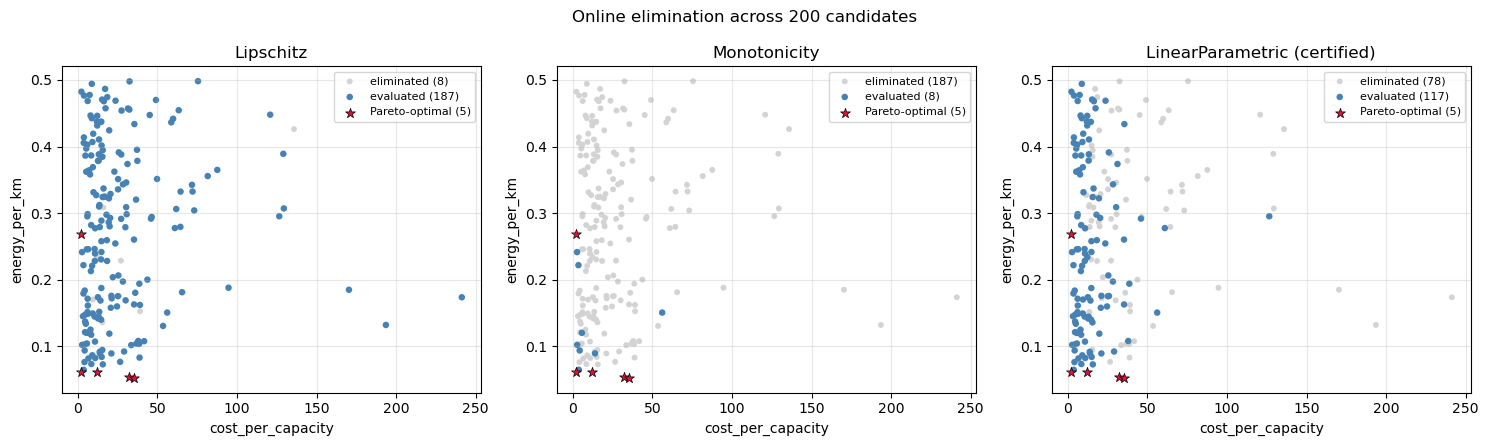

In [5]:
import matplotlib.pyplot as plt

pareto_names = {p["name"] for p in pareto}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (label, res) in zip(axes, results):
    evaluated  = {candidates[i]["name"] for i in res.evaluated_ids}
    eliminated = {candidates[i]["name"] for i in res.eliminated_ids}
    xe, ye, xx, yx, xp, yp = [], [], [], [], [], []
    for c in candidates:
        x, y = c["cost_per_capacity"], c["energy_per_km"]
        if c["name"] in pareto_names: xp.append(x); yp.append(y)
        elif c["name"] in evaluated: xe.append(x); ye.append(y)
        elif c["name"] in eliminated: xx.append(x); yx.append(y)
    ax.scatter(xx, yx, c="lightgrey", s=18, label=f"eliminated ({len(eliminated)})", edgecolor="none")
    ax.scatter(xe, ye, c="steelblue", s=22, label=f"evaluated ({len(evaluated) - len(pareto_names & evaluated)})", edgecolor="none")
    ax.scatter(xp, yp, c="crimson", s=55, marker="*", label=f"Pareto-optimal ({len(pareto_names)})", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("cost_per_capacity")
    ax.set_ylabel("energy_per_km")
    ax.set_title(label)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Online elimination across 200 candidates")
fig.tight_layout()
plt.show()

## Reading the picture

- **Lipschitz** is conservative: with the L values we picked, almost every candidate gets evaluated. The pruning rate is modest because the Lipschitz bound only tightens by `L * distance` around each observation, so distant candidates remain plausible.
- **Monotonicity** is aggressive: because `cost_per_capacity` is genuinely monotone-related to `total_cost` (it's literally proportional), one observation eliminates everything with strictly worse features. Most of the catalog gets ruled out within a dozen evaluations.
- **LinearParametric** is now the *certified* bound: it evaluates 122/200 and provably recovers all five Pareto points. Because it maintains the whole polytope of linear parameter vectors consistent with the observations (rather than a single OLS fit with a confidence band), its lower bound can never drop a Pareto-optimal candidate. It prunes less than the local bounds here because `total_cost` is not exactly affine in the raw features; it becomes exact and aggressive only when the map truly is linear. (The former OLS +/- 3-sigma heuristic pruned harder -- about 35/200 -- but wrongly dropped one Pareto point on this seed.)

The choice between evaluators is a classical bias-variance tradeoff: stronger structural assumptions mean fewer evaluations needed. With the certified evaluators none of them can wrongly prune -- Lipschitz (with a valid L), Monotonicity (on a genuinely monotone feature), and the certified LinearParametric (on a genuinely affine map) all carry a guarantee. The remaining question is purely how much pruning you get: Monotonicity is the workhorse when you have a monotone feature, Lipschitz is the safe general default, and certified LinearParametric is exact and aggressive precisely when the resource map is linear in the features.

## Where this matters

This example uses a smooth analytic inner solve, so each evaluation is cheap and the speedup is mostly pedagogical. The real payoff appears when each inner solve is itself expensive: a multi-stage MILP, a system identification, or a co-design problem with cycles. With a 1000-entry catalog and a 100ms inner solve, going from 1000 to 50 evaluations is the difference between 100 seconds and 5.
